# Dimensionality Reduction
## 1. Feature Selection
### a. Missing value ratio

In [1]:
# Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read the data
data = pd.read_csv("data/diabetes.csv")
data. head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [3]:
# Checking the percentage of missing values in each feature
data.isnull().sum()/len(data)*100

Pregnancies                  0.000000
Glucose                      0.651042
BloodPressure                4.557292
SkinThickness               29.557292
Insulin                     48.697917
BMI                          1.432292
DiabetesPedigreeFunction     0.000000
Age                          0.000000
Outcome                      0.000000
dtype: float64

### b. Low variance filter

In [4]:
data = data.fillna(data.mean())

In [5]:
# Import MinMaxScaler and initialize it
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [6]:
#Scaling the data set
data_scaled = scaler.fit_transform(data[['Pregnancies','Glucose',"BloodPressure","SkinThickness",
                                         "Insulin","BMI","DiabetesPedigreeFunction","Age"]])

In [7]:
data_scaled = pd.DataFrame(data_scaled,columns=['Pregnancies','Glucose',"BloodPressure","SkinThickness",
                                         "Insulin","BMI","DiabetesPedigreeFunction","Age"])

In [8]:
data_scaled.std(axis=0)

Pregnancies                 0.198210
Glucose                     0.196361
BloodPressure               0.123432
SkinThickness               0.095554
Insulin                     0.102189
BMI                         0.140596
DiabetesPedigreeFunction    0.141473
Age                         0.196004
dtype: float64

### c. High correlation filter

In [9]:
data.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.127911,0.208522,0.082989,0.056027,0.021565,-0.033523,0.544341,0.221898
Glucose,0.127911,1.000000,0.218367,0.192991,0.420157,0.230941,0.137060,0.266534,0.492928
BloodPressure,0.208522,0.218367,1.000000,0.192816,0.072517,0.281268,-0.002763,0.324595,0.166074
SkinThickness,0.082989,0.192991,0.192816,1.000000,0.158139,0.542398,0.100966,0.127872,0.215299
Insulin,0.056027,0.420157,0.072517,0.158139,1.000000,0.166586,0.098634,0.136734,0.214411
BMI,0.021565,0.230941,0.281268,0.542398,0.166586,1.000000,0.153400,0.025519,0.311924
DiabetesPedigreeFunction,-0.033523,0.137060,-0.002763,0.100966,0.098634,0.153400,1.000000,0.033561,0.173844
Age,0.544341,0.266534,0.324595,0.127872,0.136734,0.025519,0.033561,1.000000,0.238356
Outcome,0.221898,0.492928,0.166074,0.215299,0.214411,0.311924,0.173844,0.238356,1.000000


### d. Random Forest

In [10]:
from sklearn.ensemble import RandomForestRegressor

data2 = data.drop('Outcome',axis=1)
df = pd.get_dummies(data2)

model = RandomForestRegressor(random_state=1,max_depth=10)
model.fit(data2,data['Outcome'])
features = df.columns
importances = model.feature_importances_
indices = np.argsort(importances)[-9:] #top 10

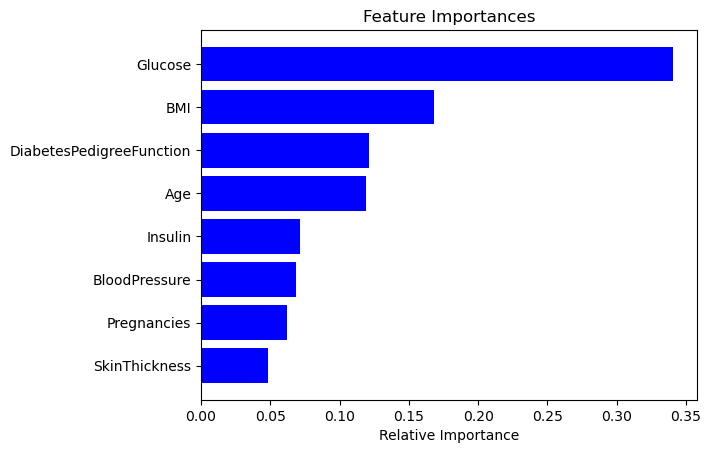

In [11]:
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## Backward Feature Elimination


Implement the backward feature elimination process to identify an optimal subset of features by iteratively removing the least significant feature based on model accuracy.


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Define the feature set X and target variable y
X = data.drop('Outcome', axis=1)
y = data['Outcome']

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize MinMaxScaler and scale the data
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print("Data preparation complete: X, y, X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled are ready.")

Data preparation complete: X, y, X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled are ready.


In [13]:
current_features = list(X.columns)
best_features_set = []
best_accuracy = 0
eliminated_features = []

print("Initialization complete: current_features, best_features_set, best_accuracy, and eliminated_features are ready.")

Initialization complete: current_features, best_features_set, best_accuracy, and eliminated_features are ready.


In [14]:
while len(current_features) > 2:
    max_accuracy_after_removal = 0
    temp_best_feature_to_remove = None

    for feature_to_consider_for_removal in current_features:
        temp_features = [f for f in current_features if f != feature_to_consider_for_removal]

        model = RandomForestClassifier(random_state=42)
        model.fit(X_train_scaled[temp_features], y_train)

        y_pred = model.predict(X_test_scaled[temp_features])
        accuracy = accuracy_score(y_test, y_pred)

        if accuracy > max_accuracy_after_removal:
            max_accuracy_after_removal = accuracy
            temp_best_feature_to_remove = feature_to_consider_for_removal

    if max_accuracy_after_removal > best_accuracy:
        best_accuracy = max_accuracy_after_removal
        current_features.remove(temp_best_feature_to_remove)
        eliminated_features.append(temp_best_feature_to_remove)
        best_features_set = list(current_features) # Update best_features_set with the current best set
    else:
        break

print("Backward Elimination Results:")
print(f"Best features set: {best_features_set}")
print(f"Best accuracy: {best_accuracy}")

Backward Elimination Results:
Best features set: ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'Age']
Best accuracy: 0.7792207792207793


## Forward Feature Selection


Implement the forward feature selection process. This involves starting with an empty set of features and iteratively adding the feature that provides the most significant improvement in model performance (accuracy) until no further significant improvement is observed. This will identify a set of recommended features.


In [15]:
selected_features = []
remaining_features = list(X_train_scaled.columns)
best_accuracy_forward = 0
best_features_set_forward = []

print("Initialization complete for Forward Feature Selection.")

Initialization complete for Forward Feature Selection.


In [16]:
while len(remaining_features) > 0:
    max_accuracy_after_addition = 0
    temp_best_feature_to_add = None

    for feature_to_consider_for_addition in remaining_features:
        temp_features = selected_features + [feature_to_consider_for_addition]

        model = RandomForestClassifier(random_state=42)
        model.fit(X_train_scaled[temp_features], y_train)

        y_pred = model.predict(X_test_scaled[temp_features])
        accuracy = accuracy_score(y_test, y_pred)

        if accuracy > max_accuracy_after_addition:
            max_accuracy_after_addition = accuracy
            temp_best_feature_to_add = feature_to_consider_for_addition

    if max_accuracy_after_addition > best_accuracy_forward:
        best_accuracy_forward = max_accuracy_after_addition
        selected_features.append(temp_best_feature_to_add)
        remaining_features.remove(temp_best_feature_to_add)
        best_features_set_forward = list(selected_features) # Update best_features_set_forward
    else:
        break

print("Forward Feature Selection Results:")
print(f"Best features set (Forward): {best_features_set_forward}")
print(f"Best accuracy (Forward): {best_accuracy_forward}")

Forward Feature Selection Results:
Best features set (Forward): ['Glucose', 'BMI', 'Pregnancies']
Best accuracy (Forward): 0.7857142857142857


## Compare Results and Summarize


Compare the feature sets obtained from both backward and forward feature elimination methods. Summarize the findings, including the features recommended for elimination or retention by each method, and discuss any agreements or discrepancies between them.


## Summary:
*   **Backward Feature Elimination**:
    *   Identified an optimal feature set of \['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'Age'] after iteratively removing features.
    *   Achieved a best accuracy of approximately 0.7793 using a RandomForestClassifier with this feature set.
*   **Forward Feature Selection**:
    *   Identified an optimal feature set of \['Glucose', 'BMI', 'Pregnancies'] by iteratively adding features.
    *   Achieved a best accuracy of approximately 0.7857 using a RandomForestClassifier with this feature set.
*   **Comparison of Feature Sets**:
    *   **Common Features**: 'Pregnancies', 'Glucose', and 'BMI' were identified as important by both methods.
    *   **Unique Features**: Backward elimination also retained 'BloodPressure' and 'Age', which were not part of the forward selection's optimal set.
*   The forward feature selection method achieved higher accuracy with a more parsimonious model (3 features vs. 5 features), suggesting that 'BloodPressure' and 'Age' might not contribute significantly to predictive power, or could even introduce noise, in combination with the other selected features.
